<a href="https://colab.research.google.com/github/sonalismore/pandas_exercises/blob/master/NLP_ChatBot_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

**DOMAIN:** Industrial safety. NLP-based Chatbot.

**CONTEXT:**  
The database comes from one of the biggest industries in Brazil and in the world.  
It is an urgent need for industries/companies around the globe to understand why employees still suffer some injuries/accidents in plants. Sometimes they also die in such environments.

**DATA DESCRIPTION:**  
The database is basically records of accidents from 12 different plants in 3 different countries.  
Each line in the data is an occurrence of an accident.

**Columns Description:**
- **Data**: Timestamp or time/date information  
- **Countries**: Which country the accident occurred (anonymized)  
- **Local**: The city where the manufacturing plant is located (anonymized)  
- **Industry sector**: Which sector the plant belongs to  
- **Accident level**: From I to VI, it registers how severe the accident was (I = not severe, VI = very severe)  
- **Potential Accident Level**: Depending on the accident level, the database also registers how severe the accident *could* have been (due to other factors)  
- **Genre**: Whether the person is male or female  
- **Employee or Third Party**: Whether the injured person is an employee or a third party  
- **Critical Risk**: Description of the risk involved in the accident  
- **Description**: Detailed description of how the accident happened  


# **Importing necessary libraries, creating dataframe**

## **Import Libraries**


In [1]:
#Import all the necessary modules
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
import copy
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from random import randint

In [2]:
import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('english')
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Importing Data**

In [3]:
#Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
data = pd.read_excel('/content/drive/MyDrive/GL_2024/Capstone-chatbot/industry_accident_safety.xls')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Unnamed: 0                425 non-null    int64         
 1   Data                      425 non-null    datetime64[ns]
 2   Countries                 425 non-null    object        
 3   Local                     425 non-null    object        
 4   Industry Sector           425 non-null    object        
 5   Accident Level            425 non-null    object        
 6   Potential Accident Level  425 non-null    object        
 7   Genre                     425 non-null    object        
 8   Employee or Third Party   425 non-null    object        
 9   Critical Risk             425 non-null    object        
 10  Description               425 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 36.7+ KB


In [6]:
data.shape

(425, 11)

In [7]:
data.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
0,0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...
1,1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...
2,2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...
3,3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...
4,4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...


Observations:

The data-frame has 425 rows and 11 columns with the following data types:

1.   datetime64(1)
2.   int64(1)
3.   object(9)



# **Data Cleansing**

From the dataset, we need cleanse the data by doing the following

1. Remove the "Unnamed: 0" column as it is unnecessary.
2. Rename the "Data" column to "Date" since it represents date values.
3. Rename the "Countries" column to "Country".
4. Rename the "Genre" column to "Gender" to correctly reflect its content.
5. Rename the "Employee or Third Party" column to "Employee Type".
6. Check and drop Duplicate values
7. Check and drop null values
8. Extracting Date object as new columns

In [8]:
# Remove 'Unnamed: 0' column from Data frame
data.drop("Unnamed: 0", axis=1, inplace=True)

In [9]:
# Rename columns in the Data frame as mentioned above
data.rename(columns={'Data':'Date', 'Countries':'Country', 'Genre':'Gender', 'Employee or Third Party':'Employee Type'}, inplace=True)

In [10]:
# Check duplicates in a data frame
data.duplicated().sum()

7

In [11]:
#Viewing the duplicates in the Data frame
duplicates = data.duplicated()
data[duplicates]

,Date,Country,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee Type,Critical Risk,Description
77,2016-04-01,Country_01,Local_01,Mining,I,V,Male,Third Party (Remote),Others,In circumstances that two workers of the Abrat...
262,2016-12-01,Country_01,Local_03,Mining,I,IV,Male,Employee,Others,During the activity of chuteo of ore in hopper...
303,2017-01-21,Country_02,Local_02,Mining,I,I,Male,Third Party (Remote),Others,Employees engaged in the removal of material f...
345,2017-03-02,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
346,2017-03-02,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
355,2017-03-15,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,Team of the VMS Project performed soil collect...
397,2017-05-23,Country_01,Local_04,Mining,I,IV,Male,Third Party,Projection of fragments,In moments when the 02 collaborators carried o...


In [12]:
#Dropping duplicates as removing them wouldnt affect the overall quality of the data frame
data.drop_duplicates(inplace=True)

In [13]:
#Checking null values
data.isnull().sum()

,0
Date,0
Country,0
Local,0
Industry Sector,0
Accident Level,0
Potential Accident Level,0
Gender,0
Employee Type,0
Critical Risk,0
Description,0


In [14]:
# Ensure 'Date' is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract time-based features as new columns
data['Year'] = data['Date'].apply(lambda x: x.year)
data['Month'] = data['Date'].apply(lambda x: x.month)
data['Day'] = data['Date'].apply(lambda x: x.day)
data['Weekday'] = data['Date'].apply(lambda x: x.day_name())

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 424
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      418 non-null    datetime64[ns]
 1   Country                   418 non-null    object        
 2   Local                     418 non-null    object        
 3   Industry Sector           418 non-null    object        
 4   Accident Level            418 non-null    object        
 5   Potential Accident Level  418 non-null    object        
 6   Gender                    418 non-null    object        
 7   Employee Type             418 non-null    object        
 8   Critical Risk             418 non-null    object        
 9   Description               418 non-null    object        
 10  Year                      418 non-null    int64         
 11  Month                     418 non-null    int64         
 12  Day                       4

## Data Cleaning Summary

- **Removed unnecessary column:** Dropped the redundant `"Unnamed: 0"` column.
- **Renamed columns for clarity and consistency:** Renamed 4 columns for improved clarity and consistency.
- **Duplicate data handling:** Removed 7 duplicate rows after review.
- **Column List:** Dataset includes key fields such as `Date`, `Country`, `Gender`, and `Description`.
- **Null Value Check:** No missing values found in the dataset.
- Extracted **Date** object into `Year`,`Month`,`Day`, and `Weekday`.
- **Final DataFrame Overview (After Cleansing):** Final dataset contains **418 entries** and **14 columns**.
- **Data Types:** Dataset includes **1 datetime column** , **4 int column** and **9 categorical columns**.

# **EDA**

**DataSet Analysis- Basic EDA**

In [16]:
for col in data.columns:
  #print(col)
  if (data[col].dtype=='object' or data[col].dtype=='int32') and col not in ['Day','Description','WeekOfYear']:
    data[col]=pd.Categorical(data[col])


In [17]:
cat_cols=data.select_dtypes(include=['category']).columns
for col in cat_cols:
  print(data[col].value_counts())
  print('-'*50)

Country
Country_01    248
Country_02    129
Country_03     41
Name: count, dtype: int64
--------------------------------------------------
Local
Local_03    89
Local_05    59
Local_01    56
Local_04    55
Local_06    46
Local_10    41
Local_08    27
Local_02    23
Local_07    14
Local_12     4
Local_09     2
Local_11     2
Name: count, dtype: int64
--------------------------------------------------
Industry Sector
Mining    237
Metals    134
Others     47
Name: count, dtype: int64
--------------------------------------------------
Accident Level
I      309
II      40
III     31
IV      30
V        8
Name: count, dtype: int64
--------------------------------------------------
Potential Accident Level
IV     141
III    106
II      95
I       45
V       30
VI       1
Name: count, dtype: int64
--------------------------------------------------
Gender
Male      396
Female     22
Name: count, dtype: int64
--------------------------------------------------
Employee Type
Third Party           

In [18]:
def labeled_barplot(data, feature,Target, perc=False, n=None):
  total = len(data[feature])  # length of the column
  count = data[feature].nunique()
  #if n is None:
  #  plt.figure(figsize=(count + 2, 6))
  #else:
  #  plt.figure(figsize=(n + 2, 6))

  fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

  ax[0].set_title('Countplot for feature ' + feature)

  sns.countplot(
        data=data,
        x=feature,
      # hue=Target,
        palette="Paired",        ax=ax[0],
        order=data[feature].value_counts().index[:n],
  )
  ax[0].tick_params(labelrotation=90)

  for p in ax[0].patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax[0].annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=6,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

  ax[1].set_title('Countplot for feature ' + feature + ' with respect to ' + Target)
  sns.countplot(
        data=data,
        x=feature,
        hue=Target,
        palette="Paired",ax=ax[1],
        order=data[feature].value_counts().index[:n],
  )

  for p in ax[1].patches:
       if perc == True:
           label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
           #print(label)
       else:
        label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax[1].annotate(
           label,
           (x, y),
          ha="center",
          va="center",
           size=6,
            xytext=(0, 5),
            textcoords="offset points",
        )
  plt.xticks(rotation=90);
  plt.tight_layout()

In [19]:
def labeled_barplot_uni(data, feature, perc=False, n=None):
  total = len(data[feature])  # length of the column
  count = data[feature].nunique()
  if n is None:
    plt.figure(figsize=(count + 2, 6))
  else:
    plt.figure(figsize=(n + 2, 6))
  plt.xticks(rotation=90, fontsize=15)
  ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
  )
  ax.set_title('Countplot for feature ' + feature)

  for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

  plt.show()

**Univariate Analysis Countries**


In [20]:
data.head()

,Date,Country,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee Type,Critical Risk,Description,Year,Month,Day,Weekday
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,2016,1,8,Friday
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,2016,1,10,Sunday


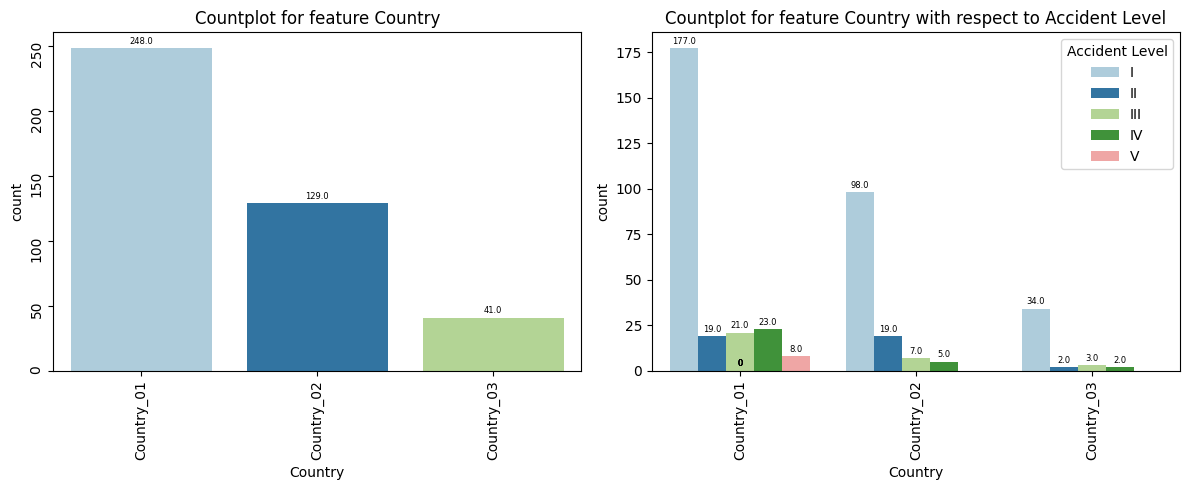

In [21]:
labeled_barplot(data,'Country', 'Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Local**

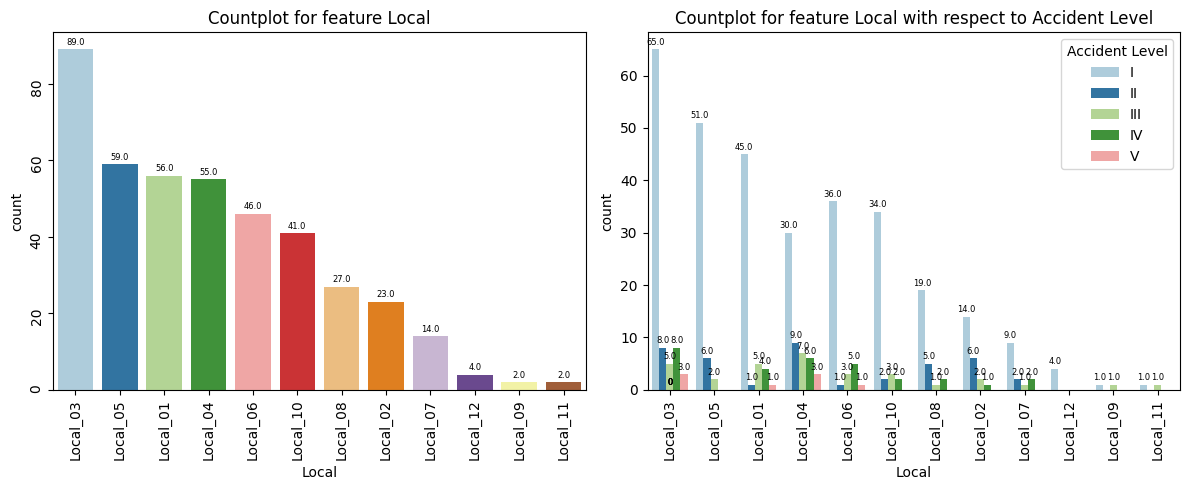

In [22]:
labeled_barplot(data,'Local', 'Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Industry Sector**

Which idustry sector has maximum chance having hazardous accidents?

**Bivariate Analysis Industry Sector with respect to Accident Level**


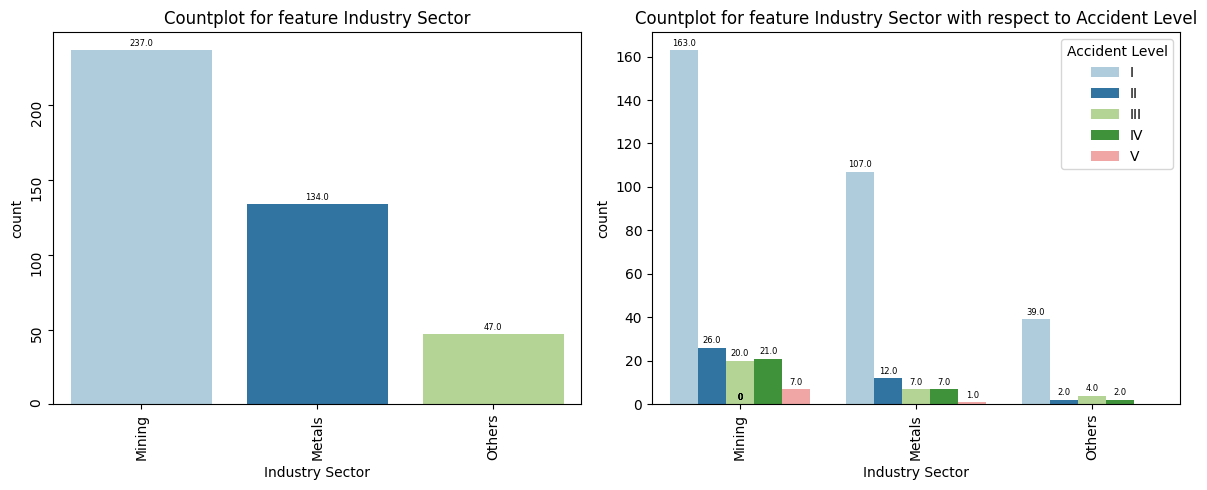

In [23]:
labeled_barplot(data,'Industry Sector', 'Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Accident Level**

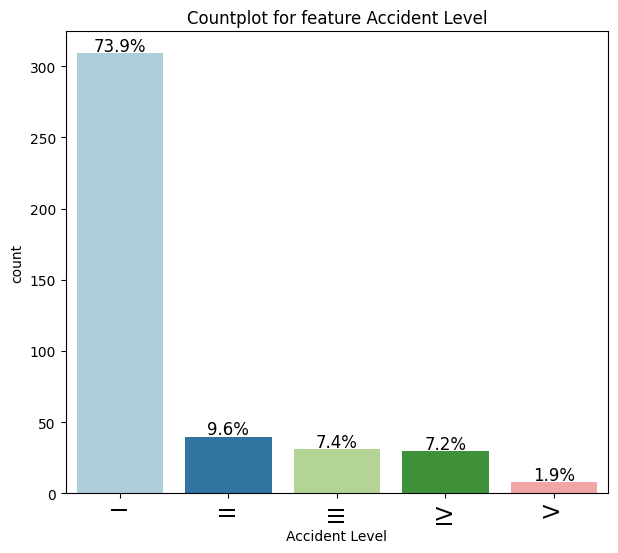

In [24]:
labeled_barplot_uni(data,'Accident Level',perc=True, n=None)

**Observation**

**Univariate Analysis Potential Accident Level**

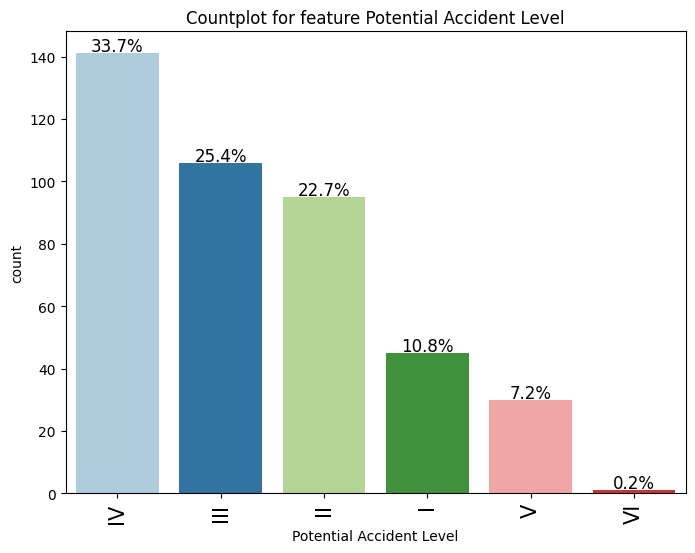

In [25]:
labeled_barplot_uni(data,'Potential Accident Level',perc=True, n=None)

**Observation**



What % of accidents have potential to turn to distaster?

**Bivariate analysis of accident level and potential accident level**


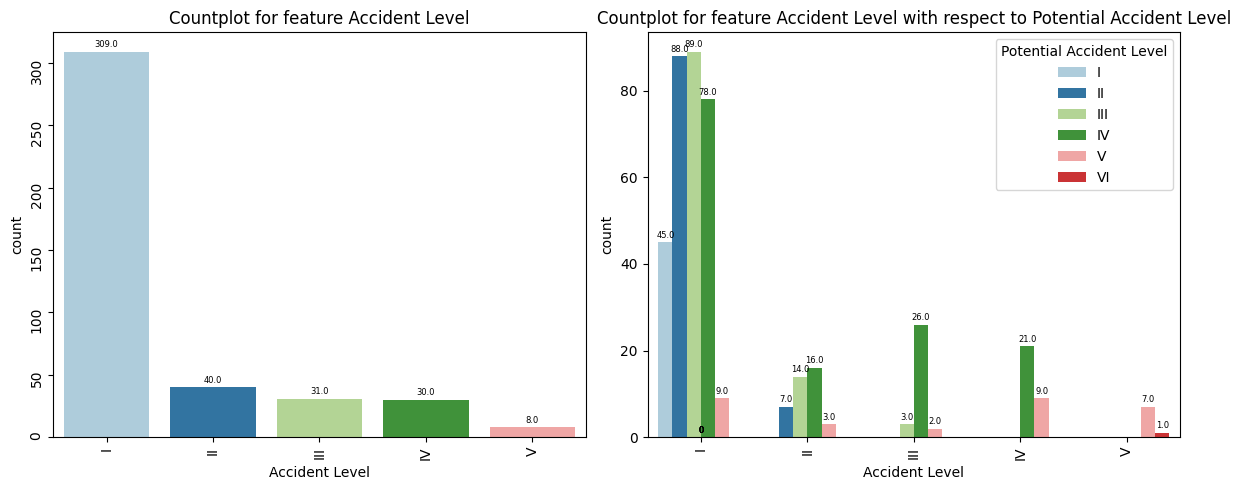

In [26]:
labeled_barplot(data,'Accident Level','Potential Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Gender**

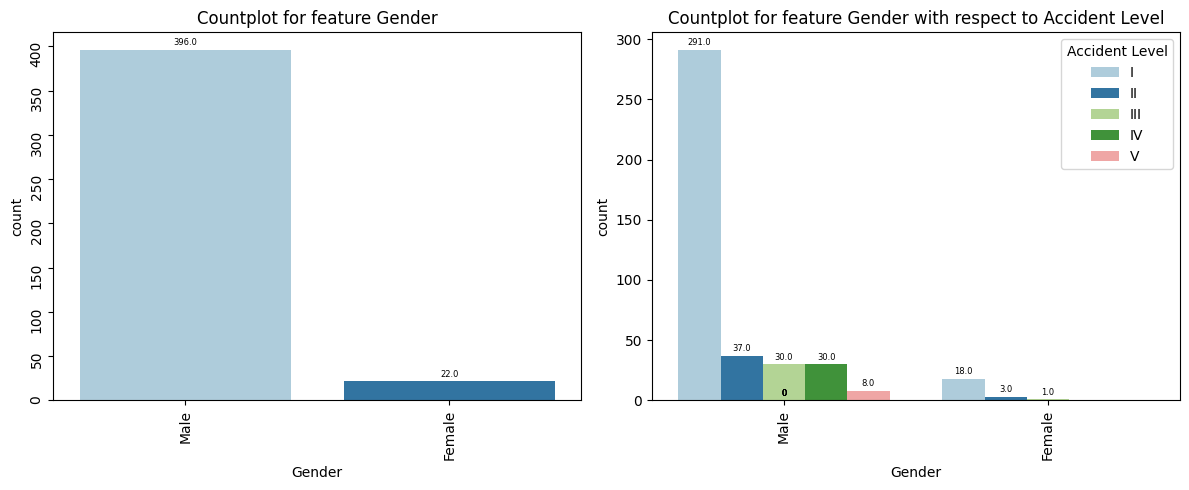

In [27]:
labeled_barplot(data,'Gender', 'Accident Level',perc=False, n=None)

**Univariate Analysis Employee Type**

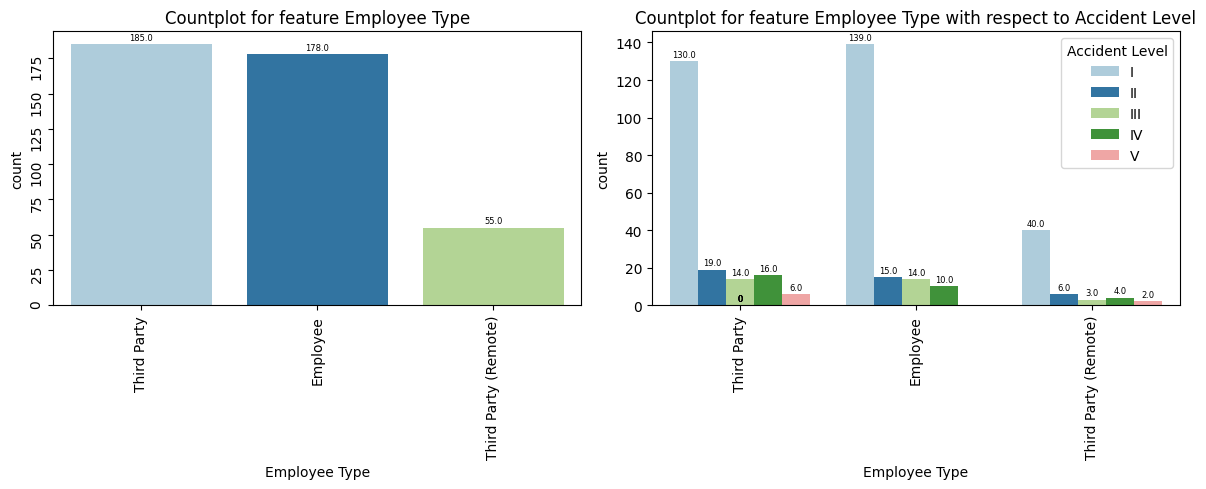

In [28]:
labeled_barplot(data,'Employee Type', 'Accident Level',perc=False, n=None)

**Observation**

**What are top 5 critical risks which have maximum chance of causing high disaster accident?**

**Univariate Analysis Critical Risk**

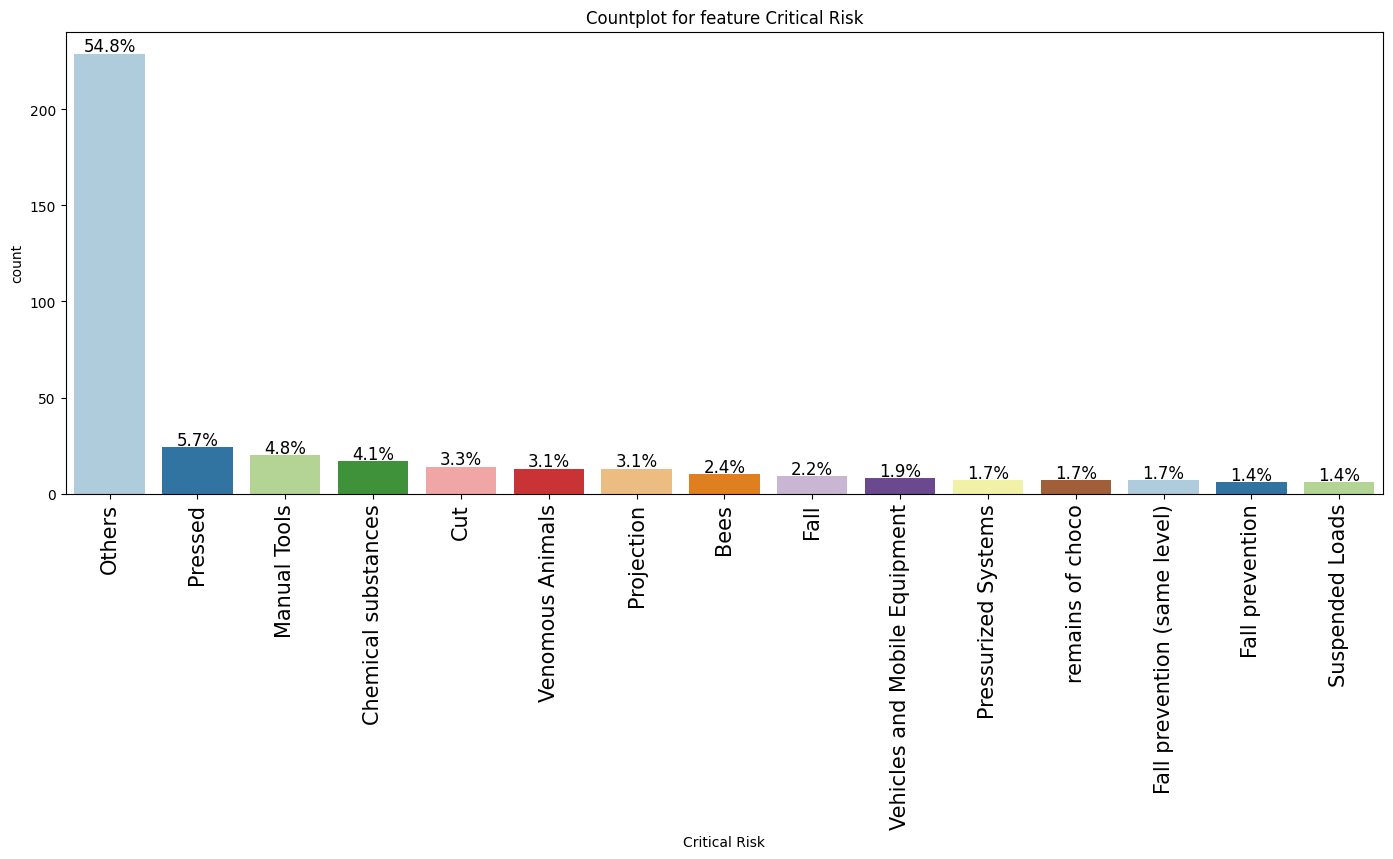

In [29]:
labeled_barplot_uni(data,'Critical Risk',perc=True, n=15)

**Observation**

**Countrywise distribution of Industry Sector-Bivariate Analysis Countries with respect to Industry Sector**

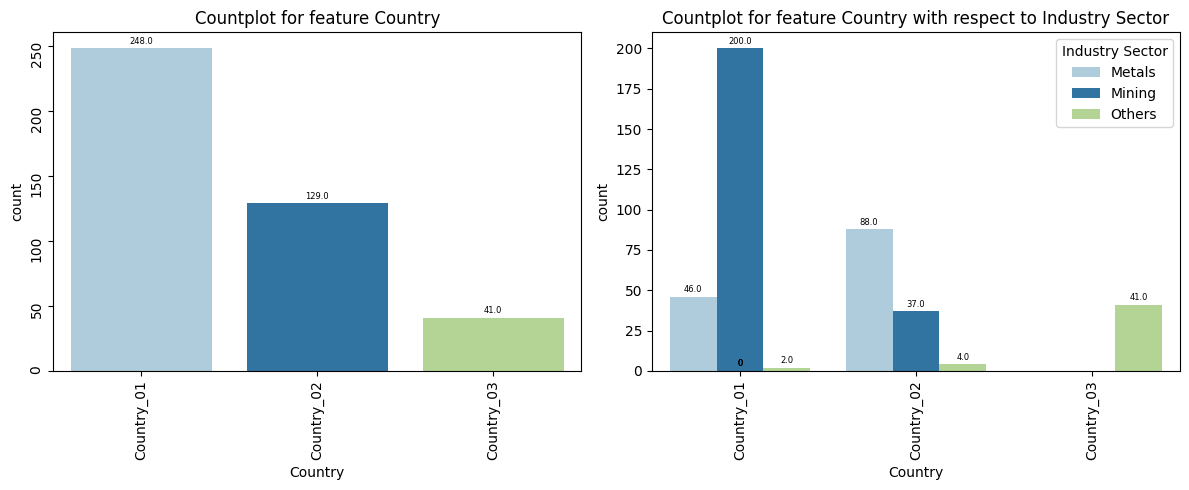

In [30]:
labeled_barplot(data,'Country', 'Industry Sector',perc=False, n=None)

**Observation**

**Bivariate Analysis Countries with respect to Gender**

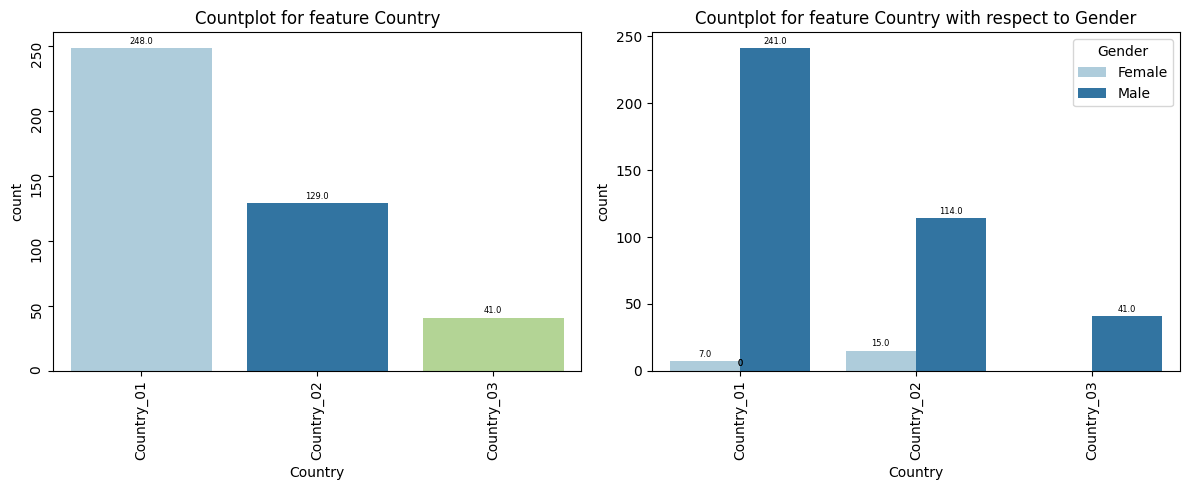

In [31]:
labeled_barplot(data,'Country', 'Gender',perc=False, n=None)

**Observation**

**Bivariate Analysis Countries with respect to Employee Type**

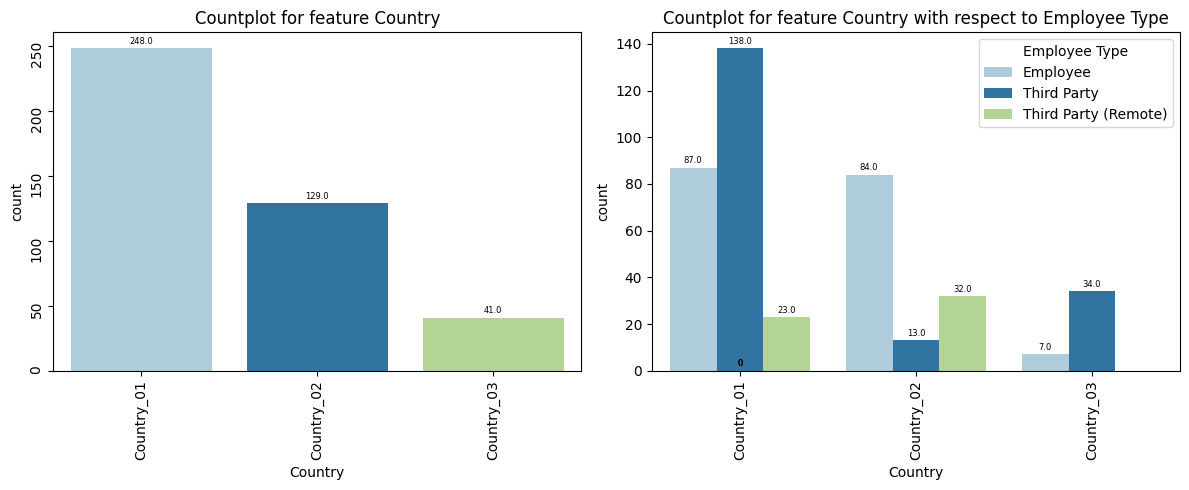

In [32]:
labeled_barplot(data,'Country', 'Employee Type',perc=False, n=None)

**Observation**

**Bivariate Analysis Industry Sector with respect to Potential Accident Level**

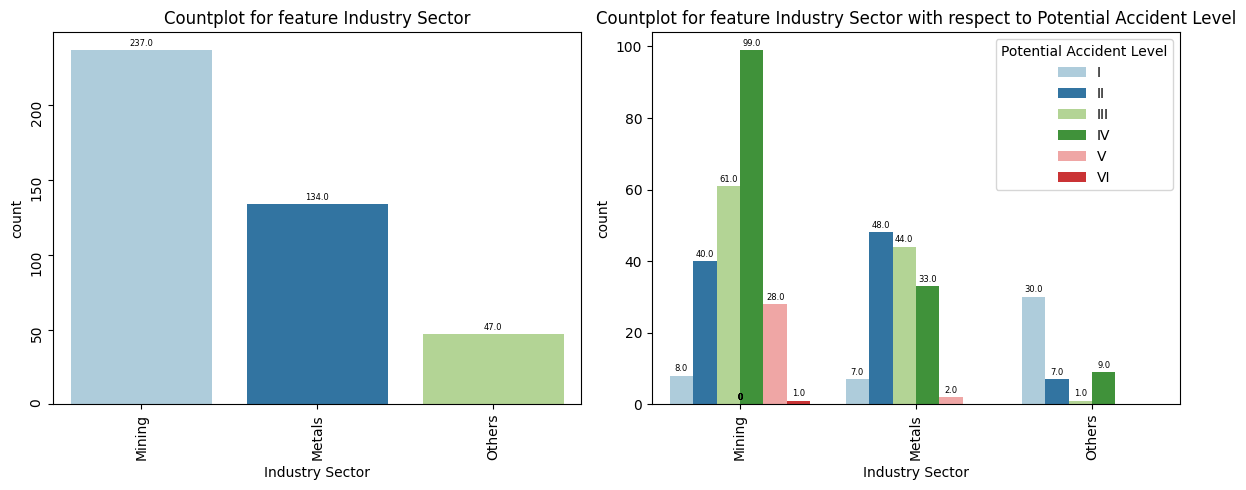

In [33]:
labeled_barplot(data,'Industry Sector', 'Potential Accident Level',perc=False, n=None)

**Observation**

**Bivariate Analysis Industry Sector with respect to Gender**

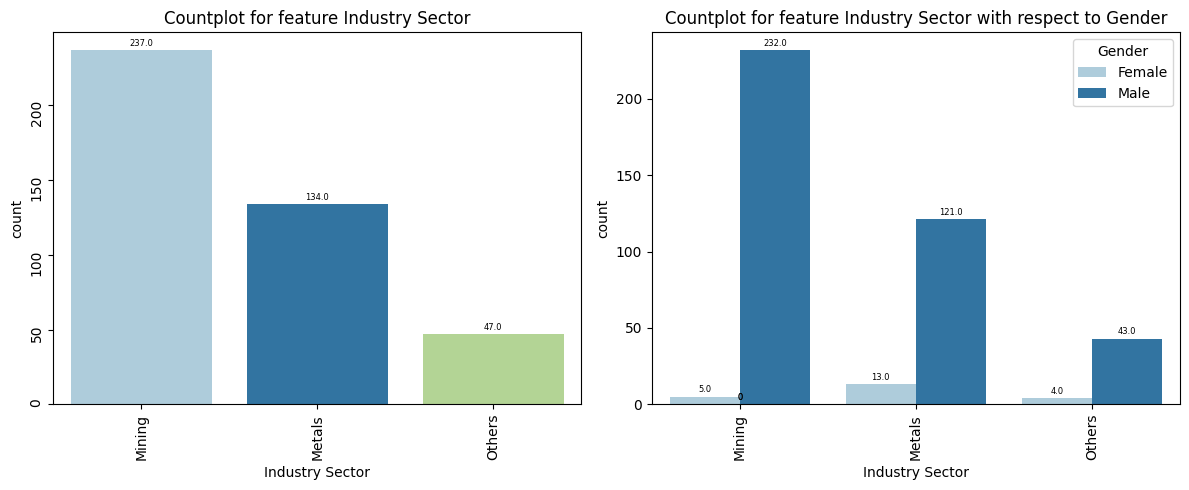

In [34]:
labeled_barplot(data,'Industry Sector', 'Gender',perc=False, n=None)

**Observation**

**Bivariate Analysis Industry Sector with respect to Employee Type**

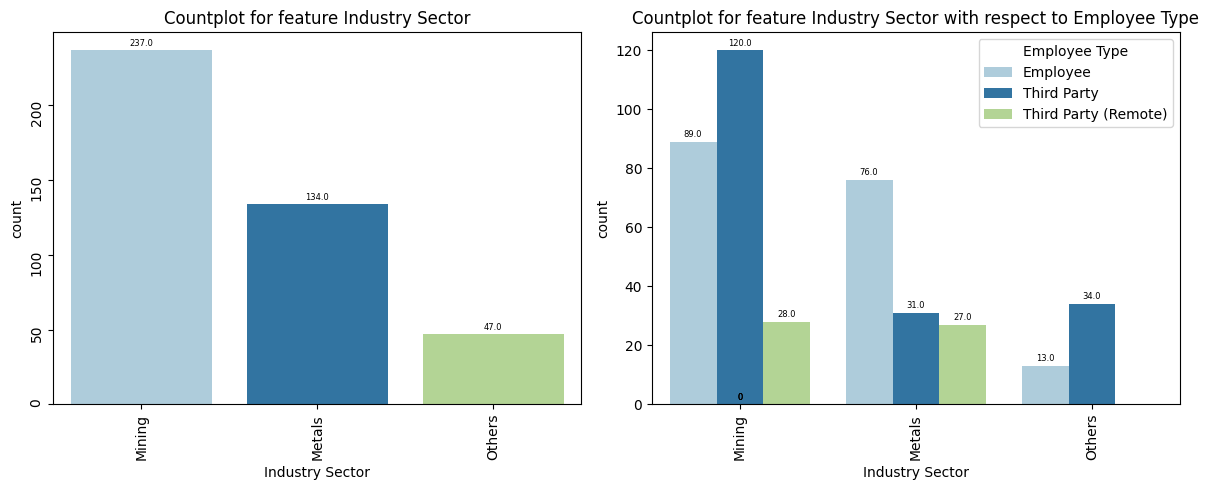

In [35]:
labeled_barplot(data,'Industry Sector', 'Employee Type',perc=False, n=None)

**Observation**

**Distribution of Employee type by Gender**

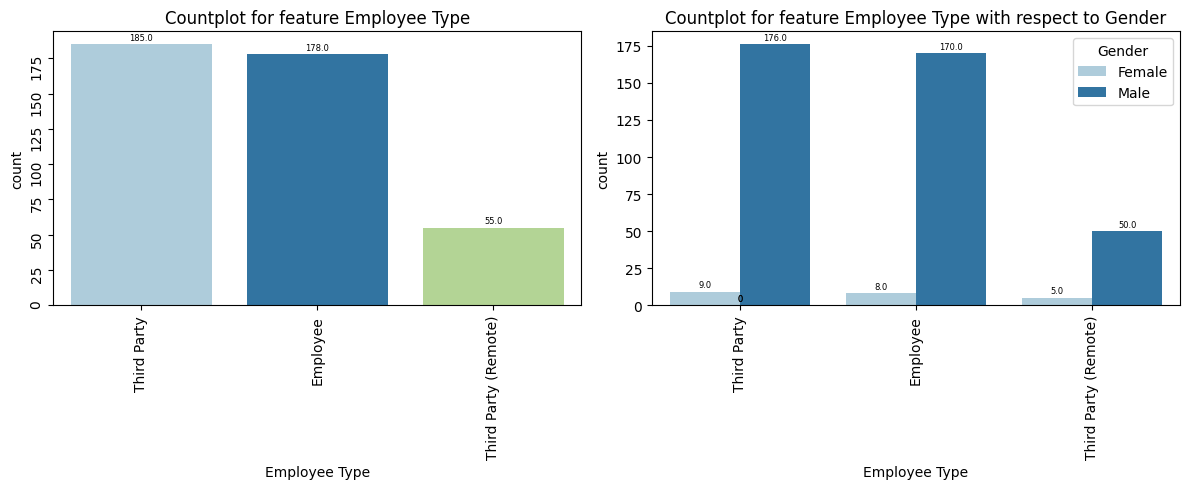

In [36]:
labeled_barplot(data,'Employee Type','Gender',perc=False, n=None)

**Observation**

**What is year wise distribution of accidents?**

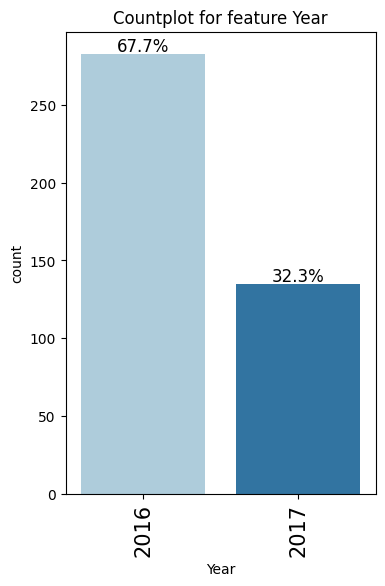

In [37]:
labeled_barplot_uni(data,'Year',perc=True, n=None)

**Observation**

**What is month wise distribution of accidents?**

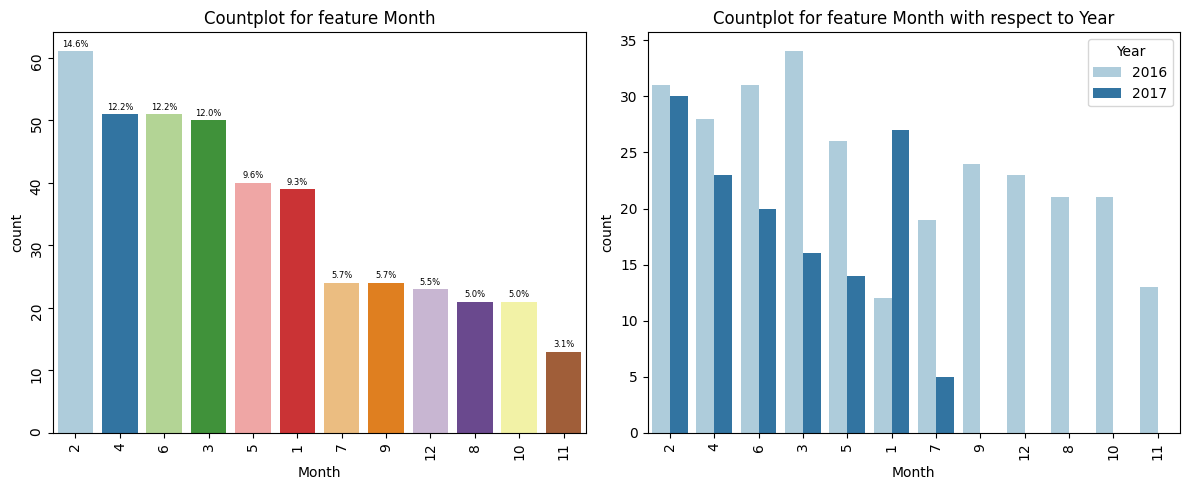

In [38]:
labeled_barplot(data,'Month','Year',perc=True, n=None)

**Observation**

**Which Year has caused maximum high risk accidents?-Accident level by Year**

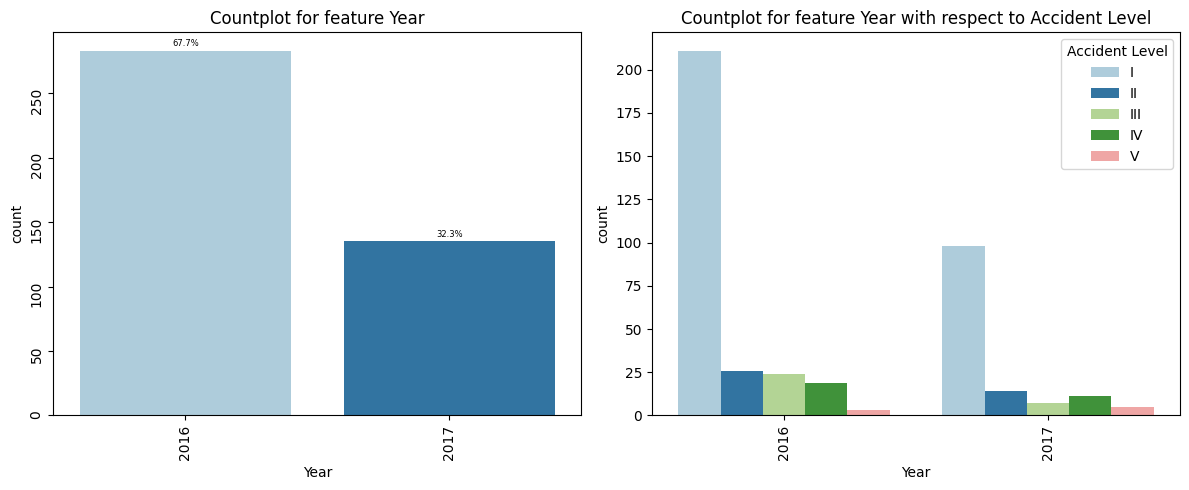

In [39]:
labeled_barplot(data,'Year','Accident Level',perc=True, n=None)

**Observation**

**What is year wise and country wise distribution of accidents?**

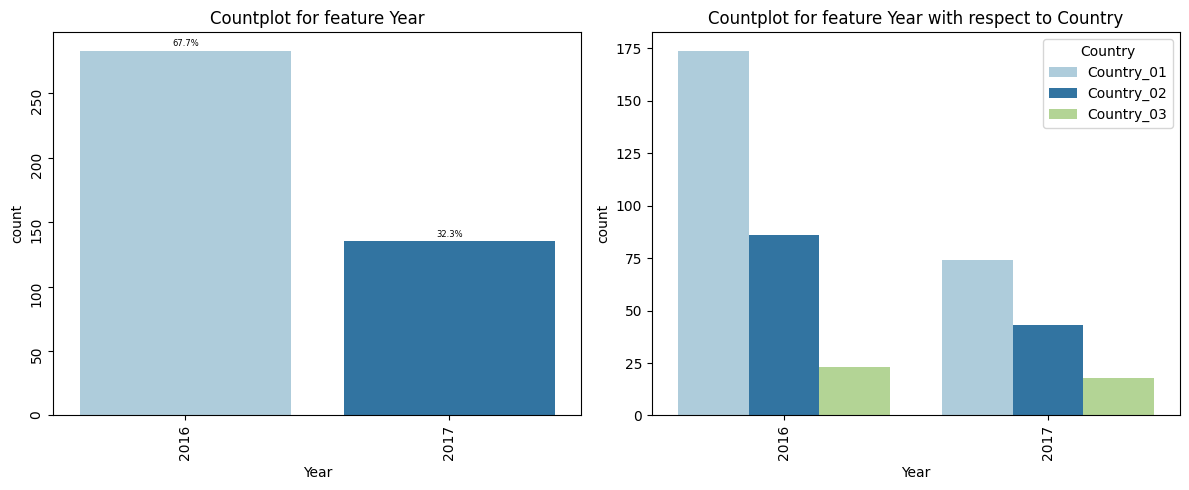

In [40]:
labeled_barplot(data,'Year','Country',perc=True, n=None)

**Observation**

**Which Month has caused maximum high risk accidents?-Accident level by Month**

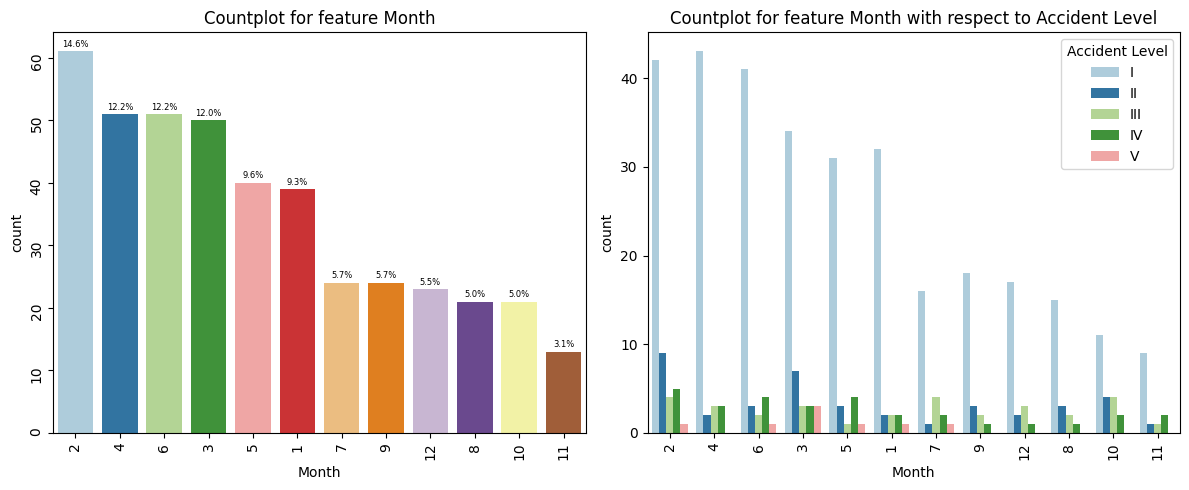

In [41]:
labeled_barplot(data,'Month','Accident Level',perc=True, n=None)

**Observation**

**Yearwise and weekdays wise distribution of accidents data**

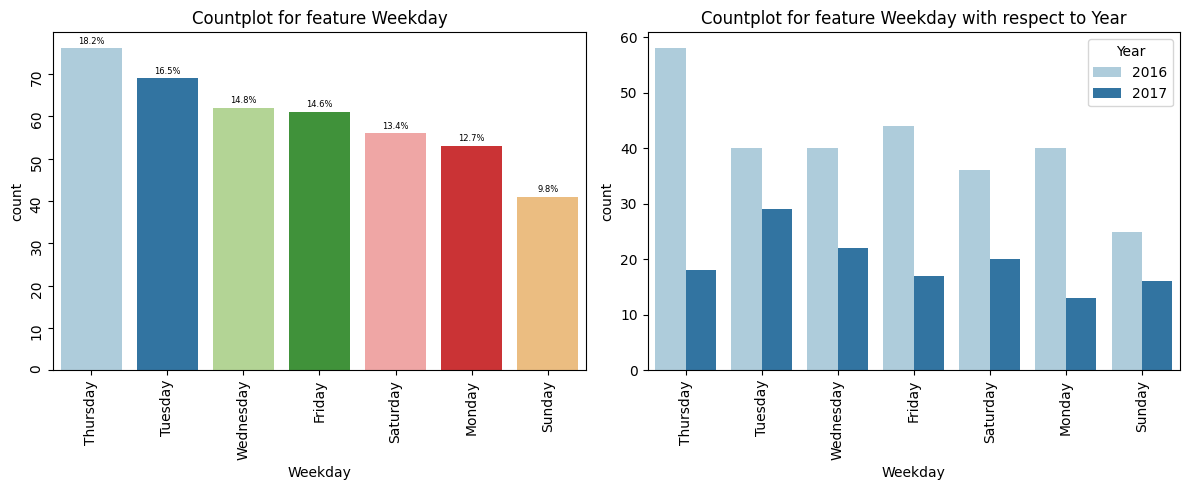

In [42]:
labeled_barplot(data,'Weekday','Year',perc=True, n=None)

**Which Weekday has caused maximum high risk accidents?-Accident level by Weekday**

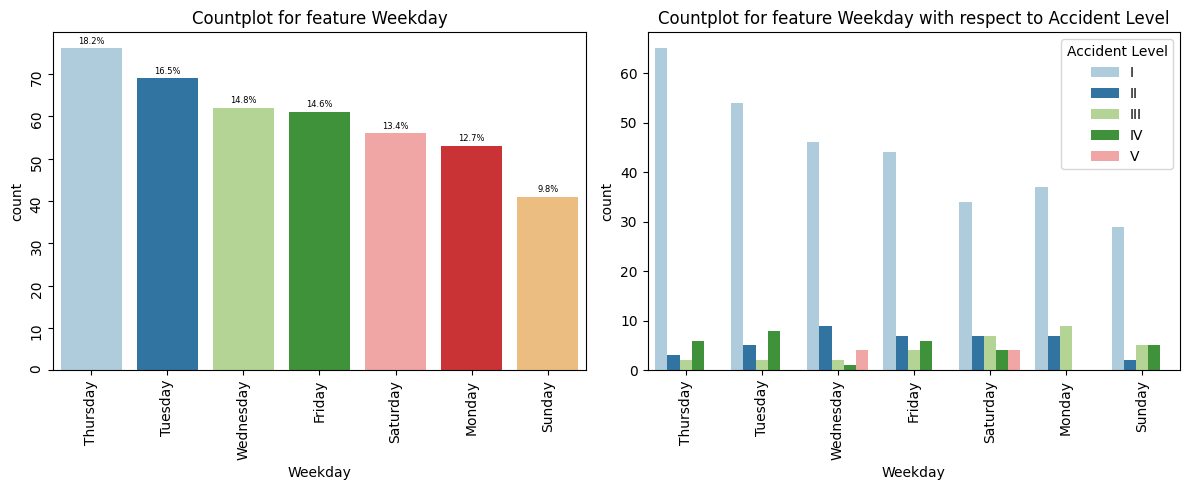

In [43]:
labeled_barplot(data,'Weekday','Accident Level',perc=True, n=None)

**Observation**

**Correlation analysis of input features**

**Chi-Square Test**


Theory: Chi-square test of independence tests the association between two categorical variables. The test is performed via contingency table or a frequency count table between the two variables. Depending on the levels that each variable has, the table’s dimension can be 2X2, 3X3 etc

**Result**

p-value < 0.05, we can reject Null Hypothesis and we can say that there is some relationship between 2 categorical variables

In [44]:
## Let us split this list into two parts
from itertools import product

cat_var1 = ('Country','Local','Industry Sector','Gender','Employee Type','Critical Risk')
cat_var2 = ('Accident Level','Potential Accident Level')
cat_var_prod = list(product(cat_var1,cat_var2, repeat = 1))
cat_var_prod

[('Country', 'Accident Level'),
 ('Country', 'Potential Accident Level'),
 ('Local', 'Accident Level'),
 ('Local', 'Potential Accident Level'),
 ('Industry Sector', 'Accident Level'),
 ('Industry Sector', 'Potential Accident Level'),
 ('Gender', 'Accident Level'),
 ('Gender', 'Potential Accident Level'),
 ('Employee Type', 'Accident Level'),
 ('Employee Type', 'Potential Accident Level'),
 ('Critical Risk', 'Accident Level'),
 ('Critical Risk', 'Potential Accident Level')]

In [45]:
## Creating an empty variable and picking only the p value from the output of Chi-Square test
import scipy.stats as ss

result = []
for i in cat_var_prod:
  if i[0] != i[1]:
    result.append((i[0],i[1],list(ss.chi2_contingency(pd.crosstab(
                            data[i[0]], data[i[1]])))[1]))
result

[('Country', 'Accident Level', 0.03528174940919625),
 ('Country', 'Potential Accident Level', 4.1017395785840915e-34),
 ('Local', 'Accident Level', 0.08571572983093331),
 ('Local', 'Potential Accident Level', 3.728976101772464e-28),
 ('Industry Sector', 'Accident Level', 0.2246610326134543),
 ('Industry Sector', 'Potential Accident Level', 1.992985715278311e-36),
 ('Gender', 'Accident Level', 0.5634711044097555),
 ('Gender', 'Potential Accident Level', 0.0003681748355215793),
 ('Employee Type', 'Accident Level', 0.3706872374960308),
 ('Employee Type', 'Potential Accident Level', 0.0723131621018394),
 ('Critical Risk', 'Accident Level', 1.3248990196998632e-06),
 ('Critical Risk', 'Potential Accident Level', 6.463580982130032e-22)]

In [46]:
chi_test_output = pd.DataFrame(result, columns = ['var1', 'var2',
                                                       'coeff'])
## Using pivot function to convert the above DataFrame into a crosstab
chi_test_output.pivot(index='var1', columns='var2', values='coeff')

var2,Accident Level,Potential Accident Level
var1,,
Country,0.035282,4.101740e-34
Critical Risk,0.000001,6.463581e-22
Employee Type,0.370687,7.231316e-02
Gender,0.563471,3.681748e-04
Industry Sector,0.224661,1.992986e-36
Local,0.085716,3.728976e-28


**DataSet Analysis- Basic EDA**

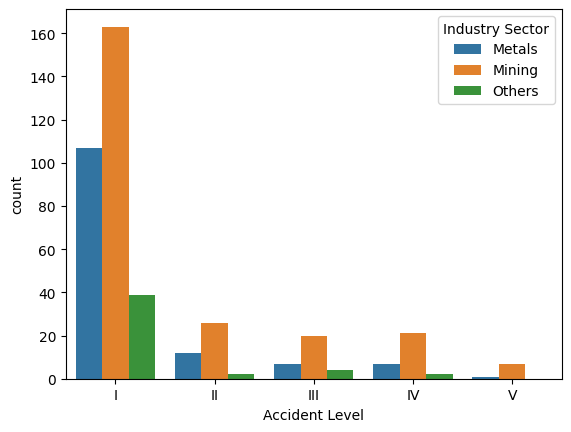

In [47]:
sns.countplot(x ='Accident Level', data = data, hue ='Industry Sector');

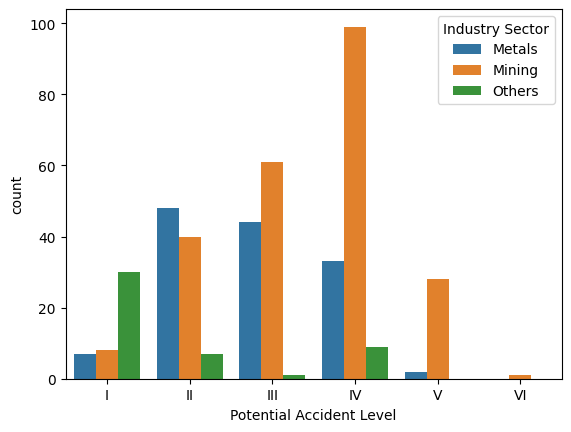

In [48]:
sns.countplot(x ='Potential Accident Level', data = data, hue ='Industry Sector');

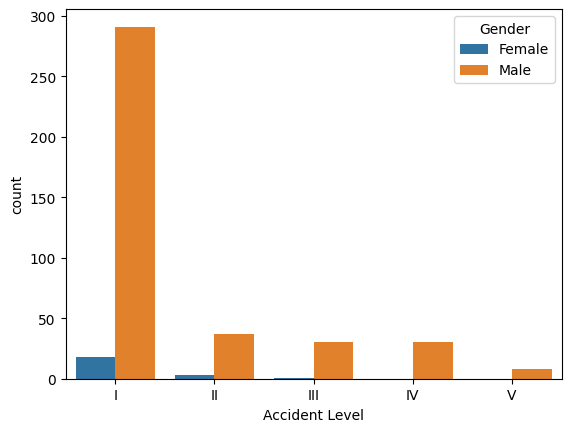

In [49]:
sns.countplot(x ='Accident Level', data = data, hue ='Gender');

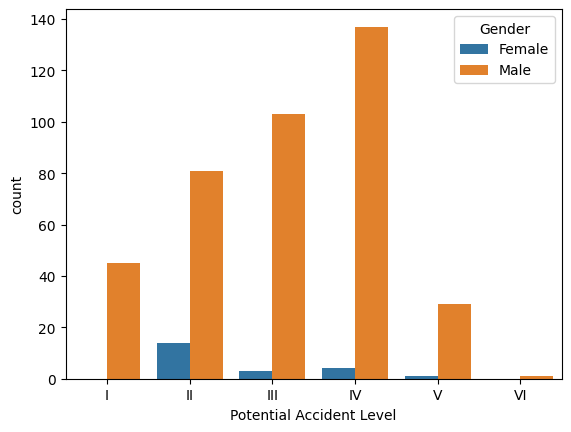

In [50]:
sns.countplot(x ='Potential Accident Level', data = data, hue ='Gender');

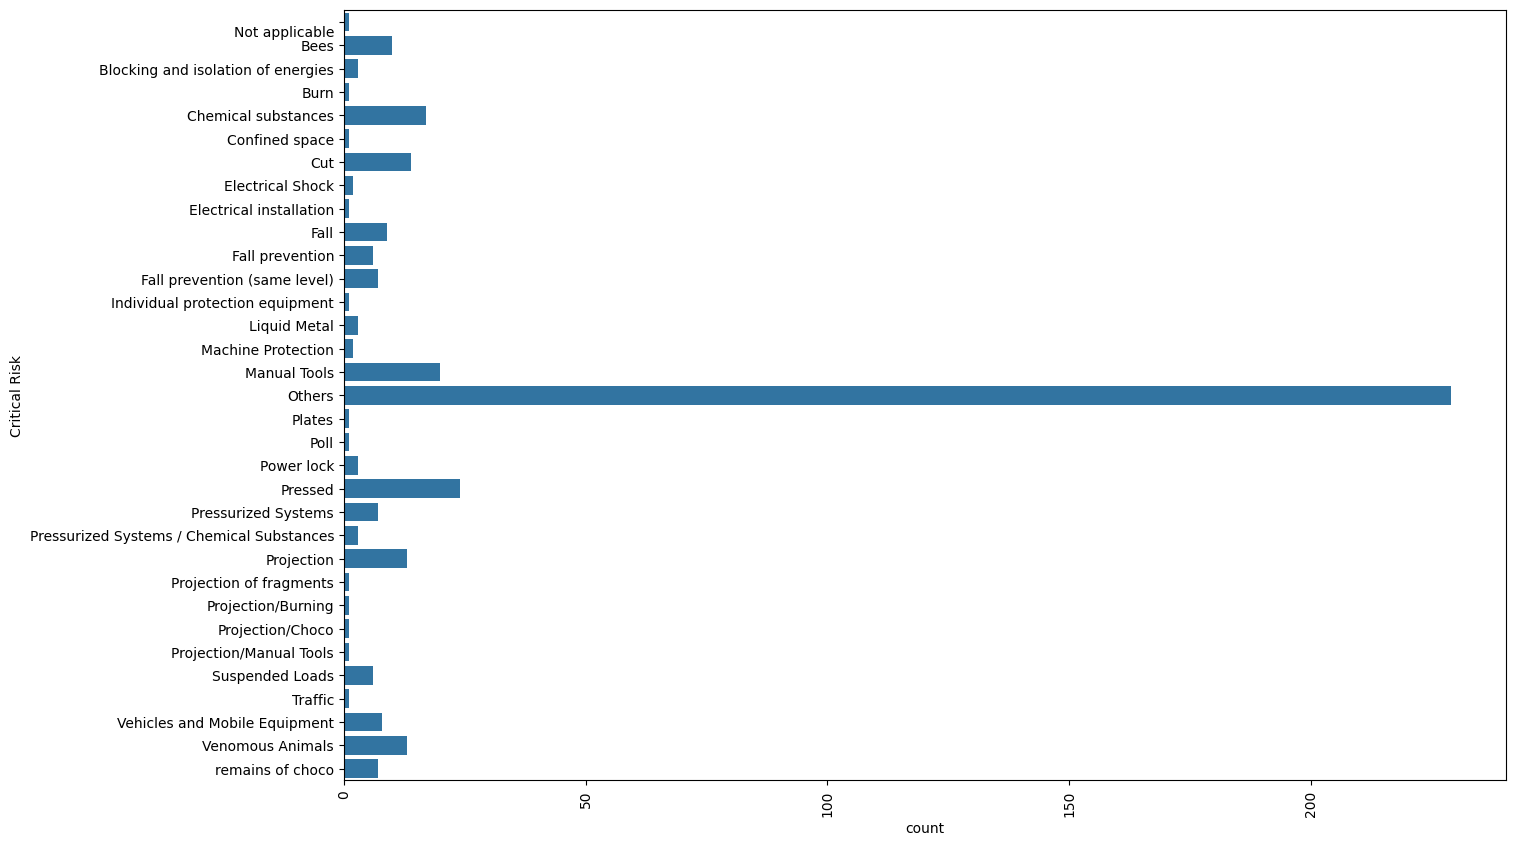

In [51]:
plt.figure(figsize=(15,10))
plt.setp(sns.countplot(data['Critical Risk']).get_xticklabels(), rotation=90);

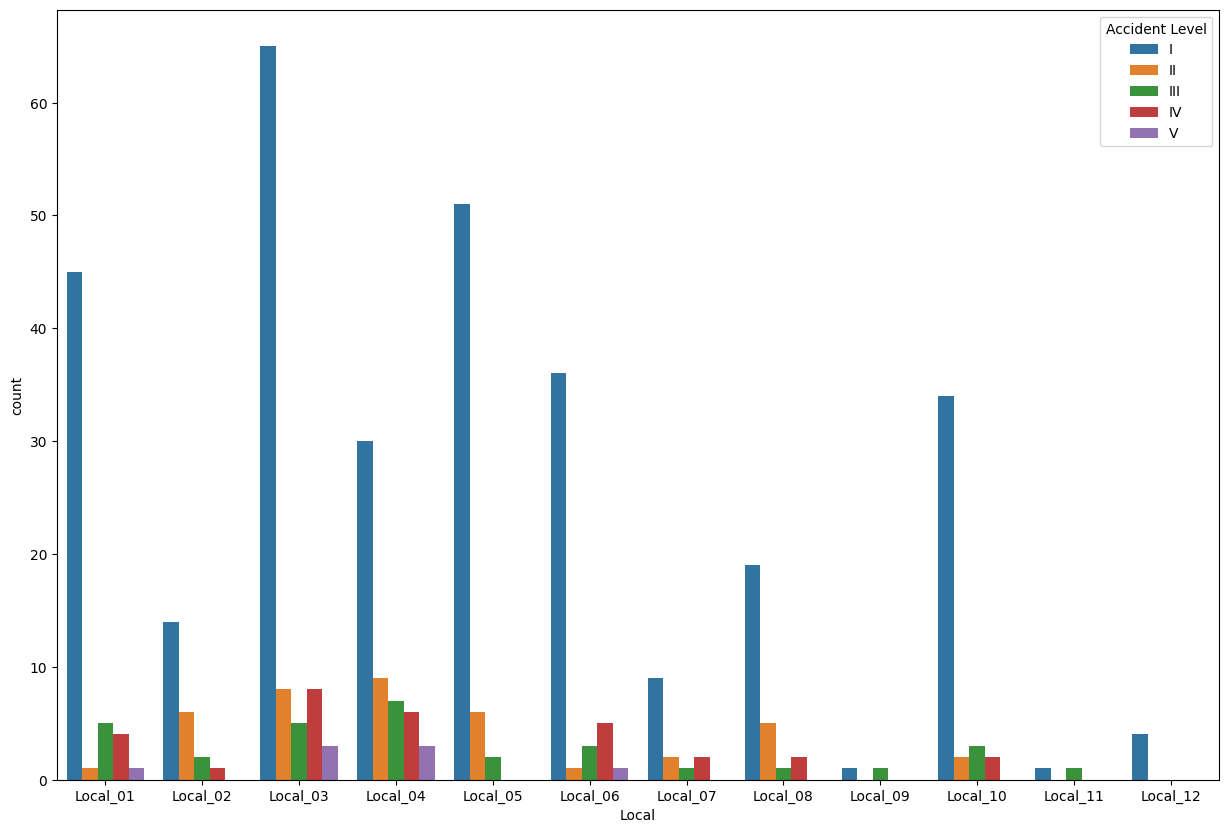

In [52]:
plt.figure(figsize=(15,10))
sns.countplot(x='Local', hue = 'Accident Level',data=data);

Labeling The Dataset

As per the dataset there are 1-5 level of Accident Level, here we have labeled 1-2 as low risk, 3-4 moderate risk and 5 critical risk

In [53]:
# Get distinct values from 'Accident Level' column
unique_levels = data['Accident Level'].unique()

# Display the unique values
print(unique_levels)

['I', 'IV', 'III', 'II', 'V']
Categories (5, object): ['I', 'II', 'III', 'IV', 'V']


In [54]:
def create_label(accident_level):
    level = str(accident_level)
    if level.__eq__("I") or level.__eq__("II"):
        return "low"
    if level.__eq__("III"):
        return "moderate"
    if level.__eq__("IV"):
        return "high"
    if level.__eq__("V"):
        return "critical"

data['Accident Severity'] = data['Accident Level'].apply(create_label)
data[['Accident Level','Accident Severity']]

,Accident Level,Accident Severity
0,I,low
1,I,low
2,I,low
3,I,low
4,IV,high
...,...,...
420,I,low
421,I,low
422,I,low
423,I,low


In [55]:
# Filter rows where Accident Severity is either 'high' or 'critical'
high_critical_df = data[data['Accident Severity'].isin(['high', 'critical'])]

# Display the result
high_critical_df[['Accident Level', 'Accident Severity', 'Description','Industry Sector']].head()


,Accident Level,Accident Severity,Description,Industry Sector
4,IV,high,Approximately at 11:45 a.m. in circumstances t...,Mining
13,IV,high,"In moments that the operator of the Jumbo 2, t...",Mining
33,V,critical,Approximately 1:40 p.m. in circumstances that ...,Mining
61,IV,high,Approximately at 11:50 a.m. in circumstances t...,Mining
67,IV,high,During the refurbishment work of the HDPE pipe...,Mining


We can see that the Mining Sector is the most risky as the most number of accidents recorded in that sector

##Pickle the dataset for reuse

In [56]:
import pickle
import numpy as np
import pandas as pd
# Loading the Porter Stemmer
ps = PorterStemmer()

In [57]:
# Save to Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_cleansed_result.pkl', 'wb') as f:
    pickle.dump(data, f)

In [58]:
# Load from Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_cleansed_result.pkl', 'rb') as f:
    data = pickle.load(f)

# **Data Preprocessing**

**Removing all irrelevant characters (Numbers and Punctuation)**

In [59]:
def remove_alpha_numerics(description_txt):
    return re.sub('[^a-zA-Z]',' ',description_txt)
data['Updated Description'] = data['Description'].apply(remove_alpha_numerics)
data['Updated Description']

,Updated Description
0,While removing the drill rod of the Jumbo f...
1,During the activation of a sodium sulphide pum...
2,In the sub station MILPO located at level ...
3,Being am approximately in the Nv C...
4,Approximately at a m in circumstances t...
...,...
420,Being approximately a m approximately w...
421,The collaborator moved from the infrastructure...
422,During the environmental monitoring activity i...
423,The Employee performed the activity of strippi...


**Convert all characters into lowercase**

In [60]:
def to_lower_case(description_txt):
    return str(description_txt).lower()
data['Updated Description'] = data['Updated Description'].apply(to_lower_case)
data['Updated Description']

,Updated Description
0,while removing the drill rod of the jumbo f...
1,during the activation of a sodium sulphide pum...
2,in the sub station milpo located at level ...
3,being am approximately in the nv c...
4,approximately at a m in circumstances t...
...,...
420,being approximately a m approximately w...
421,the collaborator moved from the infrastructure...
422,during the environmental monitoring activity i...
423,the employee performed the activity of strippi...


In [61]:
def preprocess_text(text):

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    text = ' '.join([word for word in words if word not in stopwords.words('english')])

    # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    text = ' '.join([ps.stem(word) for word in words])

    return text

In [62]:
# preprocessing the textual column
data['Updated Description'] = data['Updated Description'].apply(preprocess_text)

In [63]:
# Save to Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_preprocessed_result.pkl', 'wb') as f:
    pickle.dump(data, f)

In [64]:
# Load from Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_preprocessed_result.pkl', 'rb') as f:
    data = pickle.load(f)

## Word Embeddings

### **Word2Vec**

In [65]:
!pip install -U gensim==4.3.2

In [66]:
!pip install numpy

In [67]:
!pip install scipy==1.10.1

In [68]:
##Importing required libraries
# To import Word2Vec
from gensim.models import Word2Vec

# To tune the model
from sklearn.model_selection import GridSearchCV

# Converting the Stanford GloVe model vector format to word2vec
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

In [69]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['Updated Description'].values]

In [70]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [71]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 2366


Let's check out a few word embeddings obtained using the model.

In [72]:
# Checking the word embedding of a random word
word = "fall"
model_W2V.wv[word]

array([ 6.02578670e-02,  2.26212189e-01,  1.18827857e-01,  1.58338383e-01,
       -1.31749153e-01, -3.50087792e-01,  1.62680835e-01,  6.75421894e-01,
       -6.25530705e-02, -1.80092141e-01,  4.62873802e-02, -1.55933142e-01,
       -1.27694428e-01,  2.01760326e-02, -2.05578774e-01, -3.55074912e-01,
        2.16388762e-01,  2.85230260e-02, -1.74634084e-02, -8.91005024e-02,
       -1.10767111e-01,  3.55618633e-02,  2.35585526e-01,  1.48947611e-01,
        2.45713085e-01, -1.12096786e-01, -3.12091261e-01,  1.11716412e-01,
       -2.28254944e-01, -2.71786690e-01,  1.26139060e-01, -1.46294773e-01,
        3.69168185e-02, -4.27759066e-02, -7.99309686e-02,  4.36555743e-02,
        1.73433915e-01, -1.87926531e-01, -2.21366901e-02, -2.21961476e-02,
       -1.91203967e-01,  9.50000808e-02,  9.00960863e-02, -1.78745508e-01,
        8.98166895e-02,  3.48370880e-01,  2.43823174e-02,  2.51271546e-01,
       -5.38546108e-02,  3.10178220e-01, -5.82694681e-03,  1.04331076e-01,
       -1.93504646e-01,  

In [73]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [74]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [75]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['Updated Description'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.069225,0.272813,0.138261,0.190584,-0.160414,-0.421115,0.193997,0.807530,-0.076697,-0.218471,...,0.109805,0.453594,0.293509,0.008514,0.353121,0.274205,0.084075,-0.110647,0.356688,-0.168274
1,0.060874,0.239299,0.121155,0.167446,-0.140185,-0.369199,0.170093,0.709665,-0.067460,-0.192637,...,0.095894,0.397865,0.258100,0.008117,0.310279,0.240822,0.074102,-0.096404,0.312531,-0.147404
2,0.065008,0.256559,0.130396,0.178836,-0.150480,-0.395525,0.182582,0.758602,-0.072421,-0.204971,...,0.103430,0.425799,0.276151,0.008490,0.331608,0.257656,0.079776,-0.103730,0.334580,-0.158169
3,0.060638,0.237204,0.120561,0.165505,-0.139297,-0.365655,0.169183,0.702638,-0.066857,-0.190452,...,0.095228,0.394224,0.255697,0.008124,0.307100,0.238299,0.073534,-0.095339,0.309662,-0.146164
4,0.064238,0.253758,0.129564,0.177032,-0.148786,-0.391079,0.180839,0.751794,-0.071075,-0.203384,...,0.102473,0.422600,0.272808,0.008029,0.328478,0.255202,0.078345,-0.102565,0.330900,-0.156359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.065876,0.258414,0.131742,0.180445,-0.152124,-0.398578,0.184101,0.766162,-0.072525,-0.207246,...,0.103946,0.429695,0.278817,0.008789,0.335108,0.260295,0.080358,-0.104565,0.337897,-0.159677
414,0.064729,0.254493,0.129816,0.177582,-0.149720,-0.393172,0.181489,0.753918,-0.072129,-0.204246,...,0.102874,0.422442,0.274290,0.008477,0.329024,0.255996,0.078803,-0.103422,0.333315,-0.157601
415,0.068325,0.270573,0.137010,0.188874,-0.158901,-0.416367,0.191832,0.800588,-0.075826,-0.216890,...,0.108762,0.448952,0.290743,0.009320,0.349648,0.271914,0.083470,-0.109056,0.352603,-0.166414
416,0.065808,0.260666,0.132082,0.181515,-0.152313,-0.401744,0.185964,0.771136,-0.073250,-0.208512,...,0.105135,0.431715,0.279857,0.009035,0.337086,0.262254,0.080776,-0.105686,0.340627,-0.160820


In [76]:
# Save to Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_Word2Vec_result.pkl', 'wb') as f:
    pickle.dump(df_Word2Vec, f)

In [77]:
# Load from Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_Word2Vec_result.pkl', 'rb') as f:
    df_Word2Vec = pickle.load(f)

### **GloVe**

In [78]:
# Converting the Stanford GloVe model vector format to word2vec
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

In [79]:
# load the Stanford GloVe model
filename = '/content/drive/MyDrive/GL_2024/Capstone-chatbot/glove.6B.100d.txt.word2vec'
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GL_2024/Capstone-chatbot/glove.6B.100d.txt.word2vec'

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

In [ ]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [ ]:
vec_size=100

In [ ]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
df_Glove = pd.DataFrame(data['Updated Description'].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Glove

In [ ]:
# Save to Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_Glove_result.pkl', 'wb') as f:
    pickle.dump(df_Glove, f)

In [ ]:
# Load from Drive
with open('/content/drive/MyDrive/GL_2024/Capstone-chatbot/intermediate_Glove_result.pkl', 'rb') as f:
    df_Glove = pickle.load(f)

### **Sentence Transformer**

In [80]:
# installing the libraries for transformers
!pip install -U -q sentence-transformers transformers bitsandbytes accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.5 MB/s eta 0:00:00


In [81]:
#Importing transformer libraries
# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

In [82]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [83]:

# Deep Learning library
import torch

In [84]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(cm.shape[0], cm.shape[1])

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [85]:
## Encoding the dataset.
import torch

# If you have a GPU, use it; otherwise, use the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_matrix = model.encode(data["Description"].tolist(), show_progress_bar=True, device=device)

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

In [86]:
# Split the data
X = embedding_matrix
y = data["Potential Accident Level"]

In [87]:
# Initial split into training (80%) and testing (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42)

# Further split the temporary set into validation (10%) and test (10%) sets
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

In [88]:
print("Shape of the set of input variables for training:", X_train.shape)    # Complete the code to get the shape of training input data
print("Shape of the set of input variables for validation:", X_valid.shape)    # Complete the code to get the shape of validation input data
print("Shape of the set of input variables for testing:", X_test.shape)     # Complete the code to get the shape of testing input data

Shape of the set of input variables for training: (334, 384)
Shape of the set of input variables for validation: (42, 384)
Shape of the set of input variables for testing: (42, 384)


In [89]:
print("Shape of the set of output variables for training:", y_train.shape)    # Complete the code to get the shape of training output data
print("Shape of the set of output variables for validation:", y_valid.shape)    # Complete the code to get the shape of validation output data
print("Shape of the set of output variables for testing:", y_test.shape)     # Complete the code to get the shape of testing output data

Shape of the set of output variables for training: (334,)
Shape of the set of output variables for validation: (42,)
Shape of the set of output variables for testing: (42,)


In [90]:
class_map = {0:"Potential Accident Level",1:"Accident Level"}

In [91]:
class_map

{0: 'Potential Accident Level', 1: 'Accident Level'}

In [92]:
reverse_class_map = {}
for key,value in class_map.items():
    reverse_class_map[value]=key

reverse_class_map

{'Potential Accident Level': 0, 'Accident Level': 1}

In [93]:
## Initializing a T5 tokenizer using the pre-trained model
tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-large")

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [94]:
## Initializing a T5 model for conditional generation using the pre-trained model "google/flan-t5-large"
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-large", load_in_8bit=True, device_map="auto")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
CUDA is required but not available for bitsandbytes. Please consider installing the multi-platform enabled version of bitsandbytes, which is currently a work in progress. Please check currently supported platforms and installation instructions at https://huggingface.co/docs/bitsandbytes/main/en/installation#multi-backend


RuntimeError: CUDA is required but not available for bitsandbytes. Please consider installing the multi-platform enabled version of bitsandbytes, which is currently a work in progress. Please check currently supported platforms and installation instructions at https://huggingface.co/docs/bitsandbytes/main/en/installation#multi-backend

# Model Building

In [95]:
# Step 1: Data Cleansing
def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'[^\w\s]', '', text).lower()
        words = text.split()
        words = [word for word in words if word not in stop_words_set]
        return " ".join(words)
    return ""

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 424
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      418 non-null    datetime64[ns]
 1   Country                   418 non-null    category      
 2   Local                     418 non-null    category      
 3   Industry Sector           418 non-null    category      
 4   Accident Level            418 non-null    category      
 5   Potential Accident Level  418 non-null    category      
 6   Gender                    418 non-null    category      
 7   Employee Type             418 non-null    category      
 8   Critical Risk             418 non-null    category      
 9   Description               418 non-null    object        
 10  Year                      418 non-null    int64         
 11  Month                     418 non-null    int64         
 12  Day                       4

In [100]:
def preprocess_data(df):
    # Encode categorical features
    categorical_cols = ['Country', 'Local', 'Industry Sector', 'Gender', 'Employee Type', 'Critical Risk', 'Description']
    label_encoders = {}
    for col in categorical_cols:
        label_encoders[col] = LabelEncoder()
        df[col] = label_encoders[col].fit_transform(df[col])

    # Feature Engineering - Combine 'Critical Risk' and 'Description' for text-based features
    df['Combined_Text'] = df['Critical Risk'].astype(str) + ' ' + df['Description'].astype(str)
    df['Cleaned_Text'] = df['Combined_Text'].apply(clean_text)

    return df

In [101]:
# Download necessary NLTK resources
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords
stop_words_set = set(nltk_stopwords.words('english'))
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [102]:
from sklearn.preprocessing import LabelEncoder

cleaned_df = preprocess_data(data.copy())

In [103]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 424
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      418 non-null    datetime64[ns]
 1   Country                   418 non-null    int64         
 2   Local                     418 non-null    int64         
 3   Industry Sector           418 non-null    int64         
 4   Accident Level            418 non-null    category      
 5   Potential Accident Level  418 non-null    category      
 6   Gender                    418 non-null    int64         
 7   Employee Type             418 non-null    int64         
 8   Critical Risk             418 non-null    int64         
 9   Description               418 non-null    int64         
 10  Year                      418 non-null    int64         
 11  Month                     418 non-null    int64         
 12  Day                       4

In [104]:
# Prepare data for 'Potential Accident Level' prediction
X_potential = cleaned_df[['Country', 'Local', 'Industry Sector', 'Gender', 'Employee Type', 'Cleaned_Text']]
y_potential = cleaned_df['Potential Accident Level']

In [106]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Feature extraction for text data
tfidf_potential = TfidfVectorizer(max_features=1000) # Limit features to avoid high dimensionality
X_potential_text = tfidf_potential.fit_transform(X_potential['Cleaned_Text']).toarray()
X_potential_numerical = X_potential[['Country', 'Local', 'Industry Sector', 'Gender', 'Employee Type']].values
X_potential_final = pd.concat([pd.DataFrame(X_potential_numerical), pd.DataFrame(X_potential_text)], axis=1)


In [107]:
# Split data for 'Potential Accident Level'
from imblearn.over_sampling import RandomOverSampler

# Check class distribution
print(y_potential.value_counts())

# If classes with only one sample exist, apply oversampling
ros = RandomOverSampler(random_state=42)
X_potential_final_resampled, y_potential_resampled = ros.fit_resample(X_potential_final, y_potential)

# Now split the resampled data
X_potential_train, X_potential_test, y_potential_train, y_potential_test = train_test_split(
    X_potential_final_resampled, y_potential_resampled, test_size=0.2, random_state=42, stratify=y_potential_resampled
)

Potential Accident Level
IV     141
III    106
II      95
I       45
V       30
VI       1
Name: count, dtype: int64


In [109]:
# the classification models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# ensemble models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# methods and classes for evaluation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score, roc_auc_score

# cross-validation methods
from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# feature selection methods
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [123]:
# Train and evaluate classifiers for 'Potential Accident Level'
classifiers_potential = {
    #'Decision Tree': DecisionTreeClassifier(random_state=42),
    #'Random Forest': RandomForestClassifier(random_state=42),
    #'SVC': SVC(random_state=42),
    #'Naive Bayes': GaussianNB(),
    #'KNN': KNeighborsClassifier()
    'LogisticRegression':LogisticRegression(solver='lbfgs', multi_class='multinomial', random_state = 1),
     'RidgeClassifier':RidgeClassifier(random_state = 1),
        #'Lasso',Lasso(random_state = 1),
     'KNeighborsClassifier':KNeighborsClassifier(n_neighbors = 3),
     'SVC':SVC(kernel = 'rbf', probability=True),
     'DecisionTreeClassifier':DecisionTreeClassifier(criterion = 'gini', random_state=1),
     'RandomForestClassifier':RandomForestClassifier(n_estimators=10, random_state=1),
     'BaggingClassifier':BaggingClassifier(n_estimators=30, max_samples=0.75, random_state=1, oob_score=True),
     'AdaBoostClassifier':AdaBoostClassifier(n_estimators=100, learning_rate=0.25, random_state=1),
      'GradientBoostingClassifier':GradientBoostingClassifier(loss='log_loss', n_estimators=50, learning_rate=0.1, validation_fraction=0.2,
                                       random_state=1),
     # 'LGBMClassifier':LGBMClassifier(random_state=1, metric = "multi_logloss", objective="multiclass")
}

In [125]:
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,model_name,i_x_train,i_x_test,i_y_train,i_y_test):
    '''
    model : classifier to predict values of X

    '''
    x_train=i_x_train
    y_train=i_y_train
    x_test=i_x_test
    y_test=i_y_test
    # defining an empty list to store train and test results
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)

    #Accuracy of the model
    train_acc = model.score(x_train,y_train)
    test_acc = model.score(x_test,y_test)

    #Recall of the model
    train_recall = metrics.recall_score(y_train,pred_train,average='weighted')
    test_recall = metrics.recall_score(y_test,pred_test,average='weighted')

    #Precision of the model
    train_precision = metrics.precision_score(y_train,pred_train,average='weighted')
    test_precision = metrics.precision_score(y_test,pred_test,average='weighted')

    #Precision of the model
    train_f1score = metrics.f1_score(y_train,pred_train,average='weighted')
    test_f1score = metrics.f1_score(y_test,pred_test,average='weighted')



    print(classification_report(y_test,pred_test))

    #score_list.extend((model_name,train_acc,test_acc,train_recall,train_f1score,test_recall,train_precision,test_precision,test_f1score))
    score={'model_name':model_name,'Train_accouracy':train_acc,'test_accuracy':test_acc,'train_recall':train_recall,'test_recall':test_recall,'train_precision':train_precision,'test_precision':test_precision,
           'train_f1score':train_f1score,'test_f1score':test_f1score}
    df_perf=pd.DataFrame(score,index=[0])
    return df_perf
    '''
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(x_train,y_train))
        print("Accuracy on test set : ",model.score(x_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))


    return score_list # returning the list with train and test scores
    '''

In [128]:
resultsDf_final=pd.DataFrame()

for name, classifier in classifiers_potential.items():

  classifier.fit(X_potential_train, y_potential_train)

  resultsDf=get_metrics_score(classifier,name,X_potential_train,X_potential_test,y_potential_train,y_potential_test)
        # Store the accuracy results for each model in a dataframe for final comparison
  resultsDf_final = pd.concat([resultsDf_final, resultsDf])


resultsDf_final


              precision    recall  f1-score   support

           I       0.87      0.93      0.90        28
          II       0.55      0.64      0.59        28
         III       0.63      0.43      0.51        28
          IV       0.48      0.48      0.48        29
           V       0.87      0.93      0.90        29
          VI       1.00      1.00      1.00        28

    accuracy                           0.74       170
   macro avg       0.73      0.74      0.73       170
weighted avg       0.73      0.74      0.73       170

              precision    recall  f1-score   support

           I       0.88      1.00      0.93        28
          II       0.56      0.64      0.60        28
         III       0.71      0.43      0.53        28
          IV       0.45      0.45      0.45        29
           V       0.91      1.00      0.95        29
          VI       1.00      1.00      1.00        28

    accuracy                           0.75       170
   macro avg       0.75

,model_name,Train_accouracy,test_accuracy,train_recall,test_recall,train_precision,test_precision,train_f1score,test_f1score
0,LogisticRegression,0.909763,0.735294,0.909763,0.735294,0.909937,0.732245,0.908285,0.729564
0,RidgeClassifier,0.986686,0.752941,0.986686,0.752941,0.986762,0.748800,0.986692,0.743767
0,KNeighborsClassifier,0.810651,0.688235,0.810651,0.688235,0.811619,0.673775,0.798441,0.664834
0,SVC,0.560651,0.547059,0.560651,0.547059,0.590943,0.560354,0.558134,0.533434
0,DecisionTreeClassifier,0.995562,0.770588,0.995562,0.770588,0.995627,0.769271,0.995562,0.763186
0,RandomForestClassifier,0.988166,0.776471,0.988166,0.776471,0.988191,0.761597,0.988152,0.765007
0,BaggingClassifier,0.965976,0.794118,0.965976,0.794118,0.966288,0.786687,0.965919,0.780846
0,AdaBoostClassifier,0.519231,0.500000,0.519231,0.500000,0.527357,0.521364,0.491382,0.479805
0,GradientBoostingClassifier,0.937870,0.788235,0.937870,0.788235,0.938707,0.792009,0.937820,0.782043


In [124]:
print("--- Potential Accident Level Prediction ---")
for name, clf in classifiers_potential.items():
    clf.fit(X_potential_train, y_potential_train)
    y_pred = clf.predict(X_potential_test)
    accuracy = accuracy_score(y_potential_test, y_pred)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_potential_test, y_pred))
    print("-" * 30)

--- Potential Accident Level Prediction ---
Model: LogisticRegression
Accuracy: 0.7353
              precision    recall  f1-score   support

           I       0.87      0.93      0.90        28
          II       0.55      0.64      0.59        28
         III       0.63      0.43      0.51        28
          IV       0.48      0.48      0.48        29
           V       0.87      0.93      0.90        29
          VI       1.00      1.00      1.00        28

    accuracy                           0.74       170
   macro avg       0.73      0.74      0.73       170
weighted avg       0.73      0.74      0.73       170

------------------------------
Model: RidgeClassifier
Accuracy: 0.7529
              precision    recall  f1-score   support

           I       0.88      1.00      0.93        28
          II       0.56      0.64      0.60        28
         III       0.71      0.43      0.53        28
          IV       0.45      0.45      0.45        29
           V       0.91     

## **Hyper Parameter Tuning - Potential Accident Level**

In [112]:
param_grids = {
    "Decision Tree": {"max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5, 10]},
    "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [None, 5, 10]},
    "SVC": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    "KNN": {"n_neighbors": [3, 5, 7], "metric": ["euclidean", "manhattan"]},
    "Naive Bayes": {}  # No hyperparameters for GaussianNB
}

In [113]:
best_models = {}
performance_results = []  # Store performance metrics

# Perform GridSearchCV for each model
for model_name, param_grid in param_grids.items():
    if model_name == "Naive Bayes":
        model = GaussianNB()
    elif model_name == "Decision Tree":
        model = DecisionTreeClassifier()
    elif model_name == "Random Forest":
        model = RandomForestClassifier()
    elif model_name == "SVC":
        model = SVC()
    elif model_name == "KNN":
        model = KNeighborsClassifier()

    # Skip GridSearchCV for Naive Bayes as it has no hyperparameters
    if param_grid:
        grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
        grid.fit(X_potential_train, y_potential_train)
        best_models[model_name] = grid.best_estimator_ # Store the best estimator from GridSearchCV
        print(f"Best parameters for {model_name}: {grid.best_params_}")
    else:
        model.fit(X_potential_train, y_potential_train)
        best_models[model_name] = model # Store the trained model for Naive Bayes

    # Evaluate tuned model performance
    y_pred = best_models[model_name].predict(X_potential_test) # Now uses the fitted model
    acc = accuracy_score(y_potential_test, y_pred)
    precision = precision_score(y_potential_test, y_pred, average='weighted')
    recall = recall_score(y_potential_test, y_pred, average='weighted')
    f1 = f1_score(y_potential_test, y_pred, average='weighted')

    # Append performance metrics to the list
    performance_results.append([model_name, acc, precision, recall, f1])

print("\nHyperparameter tuning completed!")

performance_df = pd.DataFrame(performance_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

print("\nPerformance Comparison After Hyperparameter Tuning:")
print(performance_df.sort_values(by="Accuracy", ascending=False))

Best parameters for Decision Tree: {'max_depth': None, 'min_samples_split': 2}
Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 200}
Best parameters for SVC: {'C': 1, 'kernel': 'linear'}
Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 3}

Hyperparameter tuning completed!

Performance Comparison After Hyperparameter Tuning:
           Model  Accuracy  Precision    Recall  F1 Score
1  Random Forest  0.811765   0.805674  0.811765  0.804100
0  Decision Tree  0.770588   0.763895  0.770588  0.763234
2            SVC  0.764706   0.773027  0.764706  0.757713
3            KNN  0.688235   0.673775  0.688235  0.664834
4    Naive Bayes  0.647059   0.729110  0.647059  0.601828


Hyper-parameter tuning is not yeilding better accuracy of the models, using the base models

## Accident Level

In [114]:
# Encode 'Potential Accident Level'
label_encoder = LabelEncoder()
cleaned_df['Potential Accident Level Encoded'] = label_encoder.fit_transform(data['Potential Accident Level'])

In [115]:
cleaned_df['Potential Accident Level Encoded']

,Potential Accident Level Encoded
0,3
1,3
2,2
3,0
4,3
...,...
420,2
421,1
422,1
423,1


In [116]:
# Prepare data for 'Accident Level' prediction
X_accident = cleaned_df[['Country', 'Local', 'Industry Sector', 'Gender', 'Employee Type', 'Cleaned_Text','Potential Accident Level Encoded']]
y_accident = cleaned_df['Accident Level']

In [117]:
# Feature extraction for text data
tfidf_accident = TfidfVectorizer(max_features=1000) #
X_accident_text = tfidf_accident.fit_transform(X_accident['Cleaned_Text']).toarray()
X_accident_numerical = X_accident[['Country', 'Local', 'Industry Sector', 'Gender', 'Employee Type','Potential Accident Level Encoded']].values
X_accident_final = pd.concat([pd.DataFrame(X_accident_numerical), pd.DataFrame(X_accident_text)], axis=1)

In [118]:
# Split data for 'Accident Level'

# Check class distribution
print(y_accident.value_counts())

# If classes with only one sample exist, apply oversampling
ros = RandomOverSampler(random_state=42)
X_accident_final_resampled, y_accident_resampled = ros.fit_resample(X_accident_final, y_accident)

# Now split the resampled data
X_accident_train, X_accident_test, y_accident_train, y_accident_test = train_test_split(
    X_accident_final_resampled, y_accident_resampled, test_size=0.2, random_state=42, stratify=y_accident_resampled
)

Accident Level
I      309
II      40
III     31
IV      30
V        8
Name: count, dtype: int64


In [119]:
# Train and evaluate classifiers for 'Accident Level'
classifiers_accident = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier()
}

In [120]:
print("--- Accident Level Prediction ---")
for name, clf in classifiers_accident.items():
    clf.fit(X_accident_train, y_accident_train)
    y_pred = clf.predict(X_accident_test)
    accuracy = accuracy_score(y_accident_test, y_pred)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_accident_test, y_pred))
    print("-" * 30)

--- Accident Level Prediction ---
Model: Decision Tree
Accuracy: 0.9579
              precision    recall  f1-score   support

           I       1.00      0.79      0.88        62
          II       0.86      1.00      0.92        61
         III       0.97      1.00      0.98        62
          IV       1.00      1.00      1.00        62
           V       0.98      1.00      0.99        62

    accuracy                           0.96       309
   macro avg       0.96      0.96      0.96       309
weighted avg       0.96      0.96      0.96       309

------------------------------
Model: Random Forest
Accuracy: 0.9903
              precision    recall  f1-score   support

           I       1.00      0.95      0.98        62
          II       0.98      1.00      0.99        61
         III       0.97      1.00      0.98        62
          IV       1.00      1.00      1.00        62
           V       1.00      1.00      1.00        62

    accuracy                           0.99 

With best model - Predicting Accident Level